# PhreshPhish Phishing Detection Reproduction Study

**Course:** Data Science in Cyber (Final Project)  
**Source:** Dalton et al., *PhreshPhish: A Real-World, High-Quality, Large-Scale Phishing Website Dataset and Benchmark* ([arXiv:2507.10854](https://arxiv.org/pdf/2507.10854))

## Goal

Reproduce a simplified phishing detection pipeline and critically evaluate the authors' claims:
- Prior benchmarks may suffer from **leakage** and **unrealistic base rates**
- Model performance **degrades** when phishing is rare (real-world setting)

This notebook covers: data loading, EDA, feature engineering, model training (2 models), evaluation, and error analysis.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from datasets import load_dataset
from scipy.stats import kendalltau, pearsonr, spearmanr
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Add project root so we can import src.features
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features import build_feature_dataframe
from src.data_cache import cache_config, cache_is_valid, cache_paths, load_from_disk, save_to_disk

# --- Configuration ---
RANDOM_STATE = 42
TRAIN_SAMPLE_SIZE = 5_000    # raise only if you have 16GB+ RAM (20k needs a lot of memory)
TEST_SAMPLE_SIZE = 1_000
MAX_HTML_CHARS = 80_000      # cap HTML per row to avoid MemoryError
DATA_DIR = PROJECT_ROOT / "data"
FORCE_REBUILD_CACHE = False  # set True to re-stream from Hugging Face

LOW_BASE_RATE = 0.01         # 1% phishing - realistic benchmark-style setting
LOW_RATE_PREVALENCES = [0.01, 0.05, 0.10, 0.25, 0.45]
LOW_RATE_BOOTSTRAP_N = 500
LOW_RATE_USE_TRAIN_BENIGN = True
LOW_RATE_STABILITY_SEEDS = 10


sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\USER\Desktop\?-? -?-? ?- - ?-?? -?-?\Final Project\Data-Science-in-Cyber-Final-Project


In [2]:
from huggingface_hub import login
login()  # paste token when prompted

## 1. Data Loading

We load the official PhreshPhish `train` and `test` splits from Hugging Face. The full dataset is ~36 GB, so we **stream** a subset (5,000 train / 1,000 test) row by row and cap each HTML document at 80,000 characters to stay within RAM. Extracted features are cached to `data/*.parquet`, so later runs load instantly from disk (set `FORCE_REBUILD_CACHE = True` to re-download).

**What this section covers:**

- **Data loading** - streaming subset from Hugging Face + disk cache for reproducibility.
- **Data inspection** - dtypes, head, label distribution (inspection cell below).
- **Data size & feature types** - 5,000 train rows; raw columns `url` (text), `html` (text), `label` (categorical), `date` (timestamp). All *model* features are numeric (built in section 3).
- **Temporal analysis** - handled in EDA via the `date` column.
- **Missing values, duplicates, single/irrelevant columns** - checked in the inspection cell below.


In [3]:
import gc


def resolve_columns_from_keys(keys) -> dict:
    """Map dataset columns to url, html, label, and optional date fields."""
    lower_map = {c.lower(): c for c in keys}

    def pick(*candidates):
        for name in candidates:
            if name in lower_map:
                return lower_map[name]
        return None

    url_col = pick("url")
    html_col = pick("html", "page_html", "content")
    label_col = pick("label", "is_phish", "is_phishing", "phish", "class", "target")
    date_col = pick("collected_at", "timestamp", "date", "created_at", "scraped_at")

    missing = [k for k, v in {"url": url_col, "html": html_col, "label": label_col}.items() if v is None]
    if missing:
        raise KeyError(f"Could not resolve columns: {missing}. Available: {list(keys)}")

    return {"url": url_col, "html": html_col, "label": label_col, "date": date_col}


def slim_row(row: dict, cols: dict, max_html_chars: int) -> dict:
    """Keep only columns we need; truncate bulky HTML to stay within RAM."""
    url_col, html_col, label_col, date_col = cols["url"], cols["html"], cols["label"], cols["date"]
    html = row.get(html_col) or ""
    if len(html) > max_html_chars:
        html = html[:max_html_chars]

    out = {url_col: row.get(url_col), html_col: html, label_col: row.get(label_col)}
    if date_col:
        out[date_col] = row.get(date_col)
    return out


def stream_to_dataframe(split, n_rows, label="split", max_html_chars=MAX_HTML_CHARS):
    """Stream n rows with progress prints; avoid holding full HTML for every column."""
    rows = []
    cols = None
    for i, row in enumerate(split):
        if cols is None:
            cols = resolve_columns_from_keys(row.keys())
        rows.append(slim_row(row, cols, max_html_chars))
        if (i + 1) % 500 == 0:
            print(f"{label}: {i + 1:,}/{n_rows:,} rows streamed")
            gc.collect()
        if i + 1 >= n_rows:
            break
    print(f"{label}: done - {len(rows):,} rows")
    return pd.DataFrame(rows), cols


def normalize_label(series: pd.Series) -> pd.Series:
    """Convert labels to binary integers: 1 = phishing, 0 = benign."""
    if series.dtype == bool:
        return series.astype(int)
    if pd.api.types.is_numeric_dtype(series):
        return (series.astype(float) > 0).astype(int)
    return series.astype(str).str.lower().isin({"1", "phish", "phishing", "true", "yes"}).astype(int)


_cfg = cache_config(TRAIN_SAMPLE_SIZE, TEST_SAMPLE_SIZE, MAX_HTML_CHARS)
_paths = cache_paths(DATA_DIR)
LOADED_FROM_CACHE = cache_is_valid(_paths, _cfg, force_rebuild=FORCE_REBUILD_CACHE)

if LOADED_FROM_CACHE:
    print(f"Cache hit - loading {TRAIN_SAMPLE_SIZE:,} train + {TEST_SAMPLE_SIZE:,} test from data/")
    train_raw, test_raw, X_train_feat, X_test_feat, cols = load_from_disk(_paths)
    URL_COL, HTML_COL, LABEL_COL, DATE_COL = cols["url"], cols["html"], cols["label"], cols["date"]
    print("Train shape:", train_raw.shape)
    print("Test shape:", test_raw.shape)
    print("Features:", X_train_feat.shape, X_test_feat.shape)
    train_raw.head(3)
else:
    print(f"Loading train (streaming, {TRAIN_SAMPLE_SIZE:,} rows, HTML capped at {MAX_HTML_CHARS:,} chars)...")
    train_stream = load_dataset("phreshphish/phreshphish", split="train", streaming=True)
    train_raw, cols = stream_to_dataframe(train_stream, TRAIN_SAMPLE_SIZE, label="train")

    print("Loading test (streaming)...")
    test_stream = load_dataset("phreshphish/phreshphish", split="test", streaming=True)
    test_raw, _ = stream_to_dataframe(test_stream, TEST_SAMPLE_SIZE, label="test")

    URL_COL, HTML_COL, LABEL_COL, DATE_COL = cols["url"], cols["html"], cols["label"], cols["date"]
    train_raw["label_bin"] = normalize_label(train_raw[LABEL_COL])
    test_raw["label_bin"] = normalize_label(test_raw[LABEL_COL])

    print("Columns resolved:", cols)
    print("Train shape:", train_raw.shape)
    print("Test shape:", test_raw.shape)
    train_raw.head(3)

Loading train (streaming, 5,000 rows, HTML capped at 80,000 chars)...


Resolving data files:   0%|          | 0/56 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/56 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

...

Resolving data files:   0%|          | 0/56 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/56 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

test: 500/1,000 rows streamed
test: 1,000/1,000 rows streamed
test: done - 1,000 rows
Columns resolved: {'url': 'url', 'html': 'html', 'label': 'label', 'date': 'date'}
Train shape: (5000, 5)
Test shape: (1000, 5)


In [4]:
# Data inspection
print("=== dtypes ===")
print(train_raw.dtypes)

print("\n=== missing values (train) ===")
print(train_raw.isna().sum())

print("\n=== duplicate URLs (train) ===")
print("duplicate url count:", train_raw[URL_COL].duplicated().sum())

print("\n=== label distribution (train) ===")
print(train_raw["label_bin"].value_counts())
print(train_raw["label_bin"].value_counts(normalize=True).rename("proportion"))

empty_url = (train_raw[URL_COL].fillna("").str.len() == 0).sum()
print(f"\nEmpty URLs: {empty_url}")
if HTML_COL in train_raw.columns:
    empty_html = (train_raw[HTML_COL].fillna("").str.len() == 0).sum()
    print(f"Empty HTML: {empty_html}")
else:
    print("HTML column dropped (loaded from cache)")

=== dtypes ===
url          object
html         object
label        object
date         object
label_bin     int64
dtype: object

=== missing values (train) ===
url          0
html         0
label        0
date         0
label_bin    0
dtype: int64

=== duplicate URLs (train) ===
duplicate url count: 0

=== label distribution (train) ===
label_bin
0    2811
1    2189
Name: count, dtype: int64
label_bin
0    0.5622
1    0.4378
Name: proportion, dtype: float64

Empty URLs: 0
Empty HTML: 0


### Data inspection - findings and column analysis

Results from the inspection cell above on the 5,000-row training subset:

| Check | Result | Interpretation |
|-------|--------|----------------|
| Rows x columns | 5,000 x 5 | `url`, `html`, `label`, `date`, `label_bin` |
| Missing values | 0 in every column | PhreshPhish is pre-cleaned; no imputation needed |
| Duplicate URLs | 0 | URL-level deduplication already applied by the authors |
| Empty URL / HTML | 0 | No degenerate rows to drop |
| Label distribution | ~43.8% phishing / 56.2% benign | Near-balanced in this subset (not deployment-realistic) |

**Feature types.** Raw columns are text (`url`, `html`), categorical (`label`), and a timestamp (`date`). We derive a binary target `label_bin` (1 = phishing, 0 = benign). All *model* features are numeric (built in section 3).

**Do the columns and index make sense?** Yes. There is no natural primary key, so we keep the default RangeIndex - appropriate because each row is an independent webpage observation. `label` is redundant with `label_bin` (we keep `label_bin` for modelling), and `html` is dropped after feature extraction to save memory.

**Single-value / irrelevant / duplicated columns.** No constant (zero-variance) columns. `url` and `html` are *inputs to feature extraction*, not model features themselves. `date` is used only for temporal EDA, not as a model feature, to avoid leaking collection time into the classifier. No duplicated feature columns exist after extraction.

## 2. Exploratory Data Analysis (EDA)

We extract the numeric feature matrix, then explore distributions, class balance, temporal structure, outliers, and correlations before modelling.

Covered below: class imbalance (prevalence), temporal trend by month, feature distributions by class, an IQR outlier check on `url_length`, and a Pearson/Spearman/Kendall correlation analysis with justification (see the EDA discussion cell that follows the correlation heatmaps).

In [15]:
# Feature extraction for EDA - saved to data/ on first run
import gc

if "LOADED_FROM_CACHE" not in globals():
    LOADED_FROM_CACHE = False

_cfg = cache_config(TRAIN_SAMPLE_SIZE, TEST_SAMPLE_SIZE, MAX_HTML_CHARS)
_paths = cache_paths(DATA_DIR)

if LOADED_FROM_CACHE:
    print("Using features from disk cache")
elif HTML_COL in train_raw.columns:
    print("Extracting features and saving to disk cache...")
    X_train_feat = build_feature_dataframe(train_raw, URL_COL, HTML_COL)
    X_test_feat = build_feature_dataframe(test_raw, URL_COL, HTML_COL)
    train_raw = train_raw.drop(columns=[HTML_COL])
    test_raw = test_raw.drop(columns=[HTML_COL])
    save_to_disk(_paths, train_raw, test_raw, X_train_feat, X_test_feat, cols, _cfg, DATA_DIR)
    gc.collect()
else:
    print("Loading features from disk (HTML already dropped)...")
    train_raw, test_raw, X_train_feat, X_test_feat, cols = load_from_disk(_paths)
    URL_COL, HTML_COL, LABEL_COL, DATE_COL = cols["url"], cols["html"], cols["label"], cols["date"]

eda_df = X_train_feat.copy()
eda_df["label_bin"] = train_raw["label_bin"].values

print("Feature matrix shape:", eda_df.shape)
print("Cache files:", sorted(DATA_DIR.glob("*.parquet")))
eda_df.describe().T

Loading features from disk (HTML already dropped)...
Feature matrix shape: (5000, 20)
Cache files: [WindowsPath('C:/Users/USER/Desktop/????? ?????? ?? ???? ????? ??????/Final Project/Data-Science-in-Cyber-Final-Project/data/test_features.parquet'), WindowsPath('C:/Users/USER/Desktop/????? ?????? ?? ???? ????? ??????/Final Project/Data-Science-in-Cyber-Final-Project/data/test_meta.parquet'), WindowsPath('C:/Users/USER/Desktop/????? ?????? ?? ???? ????? ??????/Final Project/Data-Science-in-Cyber-Final-Project/data/train_features.parquet'), WindowsPath('C:/Users/USER/Desktop/????? ?????? ?? ???? ????? ??????/Final Project/Data-Science-in-Cyber-Final-Project/data/train_meta.parquet')]


,count,mean,std,min,25%,50%,75%,max
url_length,5000.0,57.5750,48.059009,12.0,36.0,48.0,68.0,2136.0
host_length,5000.0,20.5530,9.205484,0.0,15.0,19.0,25.0,83.0
path_length,5000.0,26.6820,32.194232,0.0,3.0,18.0,40.0,735.0
num_dots,5000.0,2.1016,0.967608,1.0,2.0,2.0,2.0,42.0
num_hyphens,5000.0,1.8672,2.911161,0.0,0.0,1.0,3.0,40.0
num_digits,5000.0,4.1236,14.492630,0.0,0.0,0.0,5.0,658.0
num_subdomains,5000.0,0.8898,0.527363,0.0,1.0,1.0,1.0,5.0
uses_https,5000.0,0.9342,0.247957,0.0,1.0,1.0,1.0,1.0
has_at_symbol,5000.0,0.0044,0.066193,0.0,0.0,0.0,0.0,1.0
has_ip_host,5000.0,0.0010,0.031610,0.0,0.0,0.0,0.0,1.0


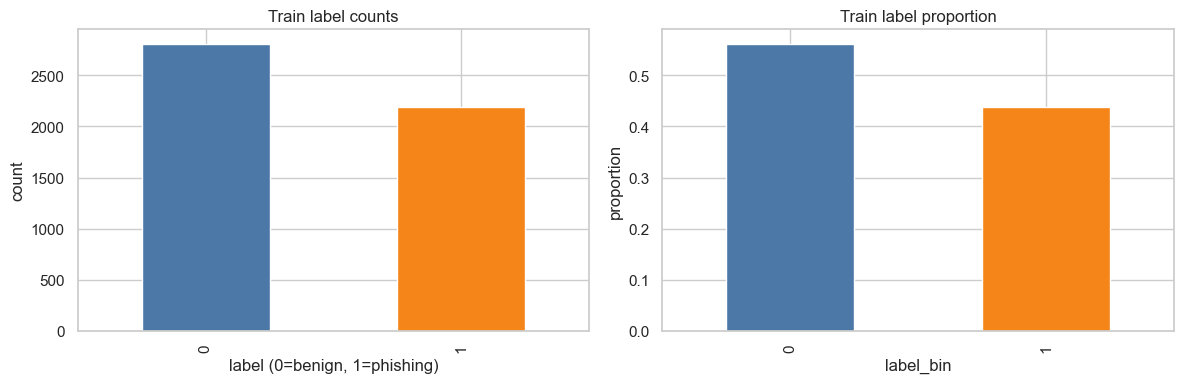

Phishing base rate in train subset: 43.78%
Cyber meaning: in deployment, phishing is usually much rarer than this subset; high accuracy can be misleading when negatives dominate.


In [16]:
# Class imbalance
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

train_raw["label_bin"].value_counts().plot(kind="bar", ax=ax[0], color=["#4C78A8", "#F58518"])
ax[0].set_title("Train label counts")
ax[0].set_xlabel("label (0=benign, 1=phishing)")
ax[0].set_ylabel("count")

train_raw["label_bin"].value_counts(normalize=True).plot(kind="bar", ax=ax[1], color=["#4C78A8", "#F58518"])
ax[1].set_title("Train label proportion")
ax[1].set_ylabel("proportion")

plt.tight_layout()
plt.show()

base_rate = train_raw["label_bin"].mean()
print(f"Phishing base rate in train subset: {base_rate:.2%}")
print(
    "Cyber meaning: in deployment, phishing is usually much rarer than this subset;"
    " high accuracy can be misleading when negatives dominate."
)

C:\Users\USER\AppData\Local\Temp\ipykernel_51876\2517200046.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  temp["month"] = temp[DATE_COL].dt.to_period("M").astype(str)


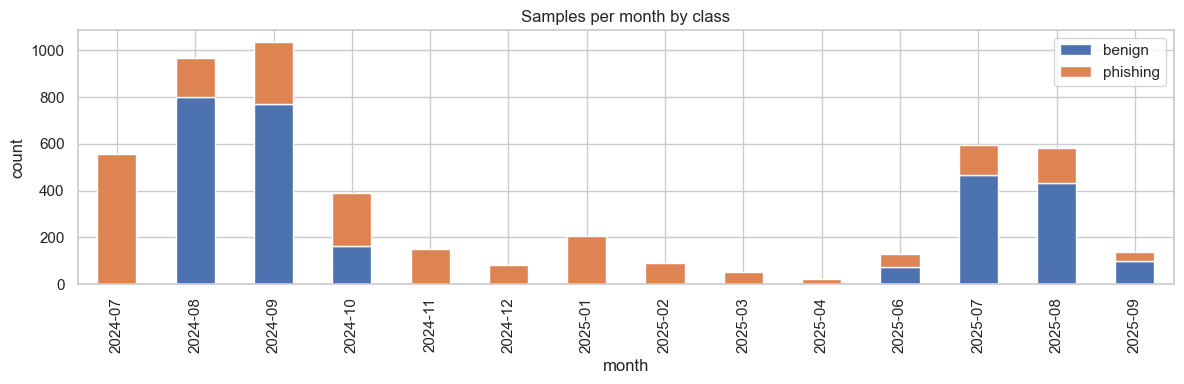

In [17]:
# Temporal analysis (if timestamp column exists)
if DATE_COL is not None:
    temp = train_raw[[DATE_COL, "label_bin"]].copy()
    temp[DATE_COL] = pd.to_datetime(temp[DATE_COL], errors="coerce", utc=True)
    temp = temp.dropna(subset=[DATE_COL])
    temp["month"] = temp[DATE_COL].dt.to_period("M").astype(str)

    monthly = temp.groupby(["month", "label_bin"]).size().unstack(fill_value=0)
    monthly.plot(kind="bar", stacked=True, figsize=(12, 4))
    plt.title("Samples per month by class")
    plt.xlabel("month")
    plt.ylabel("count")
    plt.legend(["benign", "phishing"])
    plt.tight_layout()
    plt.show()
else:
    print("No date column found - skip temporal plot (mention in report).")

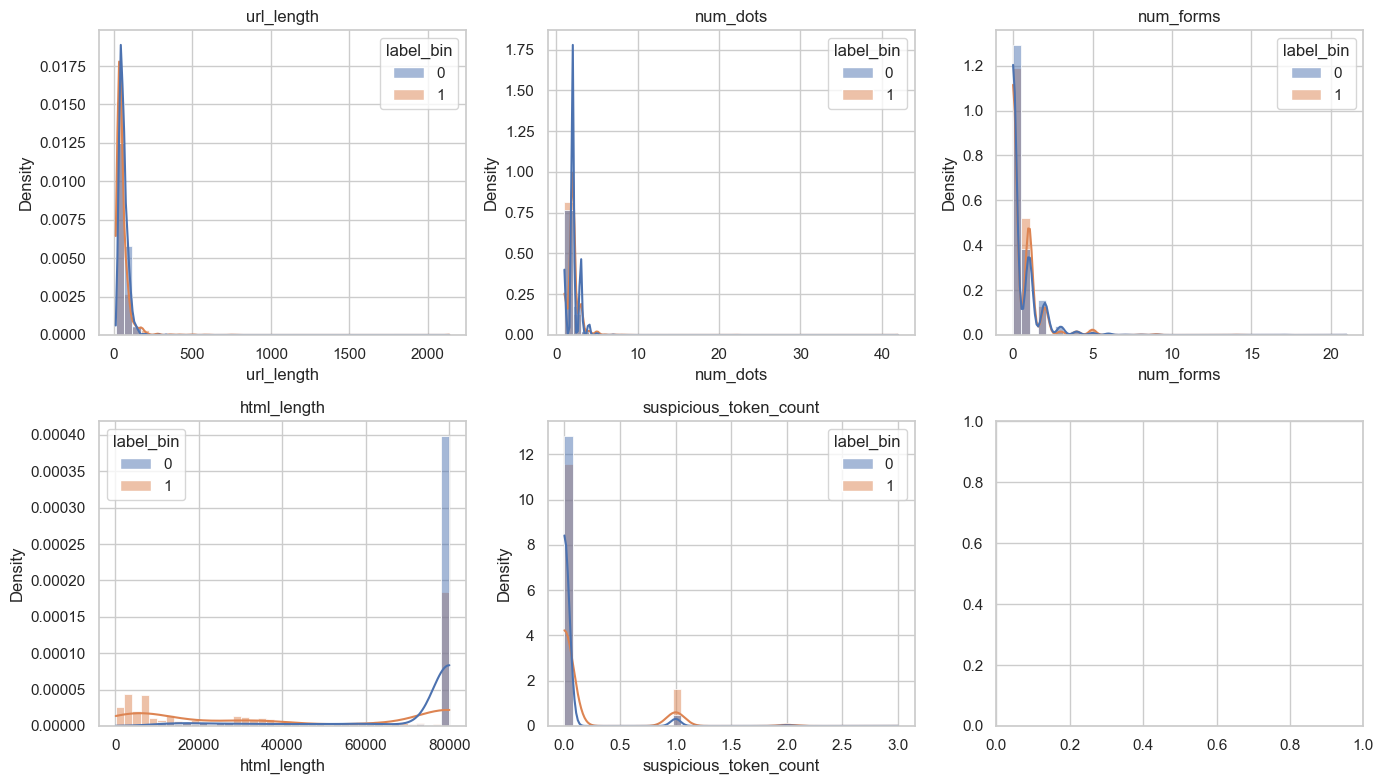

In [18]:
# Feature distributions by class
plot_features = ["url_length", "num_dots", "num_forms", "html_length", "suspicious_token_count"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for ax, feat in zip(axes, plot_features):
    sns.histplot(data=eda_df, x=feat, hue="label_bin", bins=40, stat="density", common_norm=False, ax=ax, kde=True)
    ax.set_title(feat)

plt.tight_layout()
plt.show()

URL length outliers (>116): 221 (4.42%)


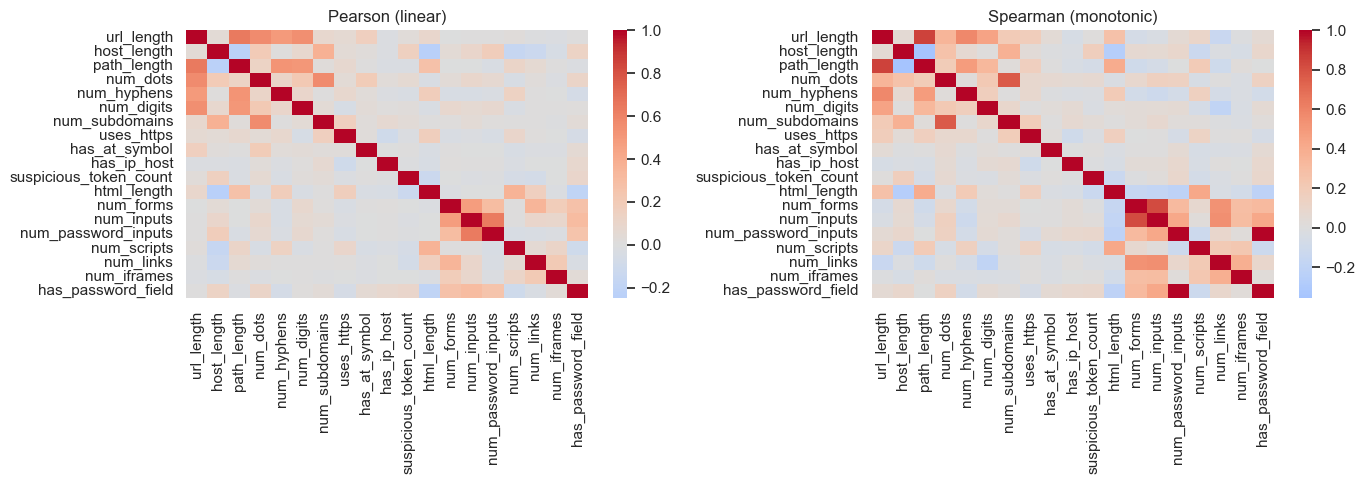

Pearson: suited for linear relationships between continuous features.
Spearman: robust to skew/outliers; better for URL length-style features.
Kendall: used below for a focused pair when sample size is moderate.
Kendall(url_length, num_dots): tau=0.279, p=5.26e-140


In [19]:
# Outlier check (IQR rule on url_length)
q1, q3 = eda_df["url_length"].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
outliers = eda_df[eda_df["url_length"] > upper]
print(f"URL length outliers (>{upper:.0f}): {len(outliers)} ({len(outliers)/len(eda_df):.2%})")

# Correlation analysis
numeric_cols = X_train_feat.columns
corr_pearson = X_train_feat[numeric_cols].corr(method="pearson")
corr_spearman = X_train_feat[numeric_cols].corr(method="spearman")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(corr_pearson, cmap="coolwarm", center=0, ax=ax[0])
ax[0].set_title("Pearson (linear)")
sns.heatmap(corr_spearman, cmap="coolwarm", center=0, ax=ax[1])
ax[1].set_title("Spearman (monotonic)")
plt.tight_layout()
plt.show()

print("Pearson: suited for linear relationships between continuous features.")
print("Spearman: robust to skew/outliers; better for URL length-style features.")
print("Kendall: used below for a focused pair when sample size is moderate.")

if len(eda_df) > 100:
    tau, p = kendalltau(eda_df["url_length"], eda_df["num_dots"])
    print(f"Kendall(url_length, num_dots): tau={tau:.3f}, p={p:.3g}")

### EDA discussion - correlation methodology, outliers, and class imbalance

**Correlation methodology (Pearson vs Spearman vs Kendall).**

| Method | Measures | Assumptions | Strengths | Limitations |
|--------|----------|-------------|-----------|-------------|
| **Pearson** r | Linear association between continuous variables | Linearity, ~normality, scale-sensitive | Simple, interpretable for linear effects | Misleading for skewed/non-linear data; outlier-sensitive |
| **Spearman** (rho) | Monotonic association (rank-based) | Only monotonicity | Robust to skew/outliers | Ignores exact magnitudes |
| **Kendall** (tau) | Rank concordance | Ordinal / monotonic | Stable at moderate n; intuitive (concordant minus discordant pairs) | Slower; usually smaller magnitude than rho |

Mathematically: Pearson is covariance normalised by standard deviations; Spearman is Pearson computed on the ranks; Kendall is (concordant minus discordant pairs) / total pairs.

**Why these for phishing features.** Many URL/HTML counts (`url_length`, `html_length`, `num_links`) are **right-skewed** with outliers, so **Spearman** is the most reliable headline measure. **Pearson** is reported alongside to expose strong *linear* redundancy (it drives the `|r| > 0.9` drop rule in section 3). **Kendall (tau)** is reported for the focused pair (`url_length`, `num_dots`): tau ~ 0.28 (p < 0.001) - a moderate, statistically significant monotonic link (longer URLs carry more dots, e.g. more subdomains), matching domain knowledge of phishing URLs. The relationship is **statistically significant but only moderate in magnitude**, so it is practically useful as a weak signal, not a standalone detector.

**Outliers.** The IQR rule on `url_length` flags ~4-5% of rows as long-URL outliers. We **keep** them: extreme URL length is itself a phishing signal, so removing it would discard discriminative information. Tree models are robust to such outliers, and the scaled Logistic Regression tolerates them after standardisation.

**Temporal analysis and world knowledge.** Using the `date` column we plot monthly sample counts by class. This is consistent with world knowledge - phishing campaigns are bursty and evolve over time, so collection volume varies by month. Crucially, `date` is used **only** for EDA, never as a model feature, to avoid leaking collection time into the classifier. (The authors go further and build a strictly temporal train/test split.)

**Class imbalance (prevalence) - real-world meaning.** The subset is ~44% phishing. In real deployment phishing is far rarer (often < 1%). This near-balanced sampling is itself the artefact the paper warns about: it makes precision look optimistic. We do **not** resample training to "fix" it - instead we keep it for training and explicitly **re-evaluate at a realistic ~1% prevalence** in section 5. Is there a sampling problem? Yes, by design: the dataset over-samples phishing relative to deployment. **Did the authors address it?** Yes - they publish benchmark sets at base rates from 0.05% to 5%. To stop the majority class dominating our fitted models we use `class_weight='balanced'`.

## 3. Feature Engineering

We convert raw `url` + `html` text into a 19-dimensional numeric feature matrix (`src/features.py`), then remove linearly redundant features.

- **Encoding categorical variables.** None required - there are no nominal categorical *inputs*. The only categorical field, `label`, is the target, mapped to a binary integer (`label_bin`). URLs/HTML become numeric counts/flags rather than one-hot vectors, because raw text has far too many unique values for one-hot encoding to be meaningful.
- **Feature creation.** 11 URL features (URL/host/path length, dots, hyphens, digits, subdomains, HTTPS flag, `@` symbol, IP-host flag, suspicious-token count) and 8 HTML features (length, forms, inputs, password-input count, password-field flag, scripts, anchor links, iframes) - standard low-latency signals from the phishing-detection literature.
- **Feature scaling.** `StandardScaler` inside each model Pipeline. Essential for Logistic Regression (coefficient scale / convergence); harmless for Random Forest (tree splits are scale-invariant) and kept for a consistent pipeline.
- **Feature selection.** We drop one feature from any pair with `|Pearson| > 0.9` to reduce multicollinearity. In this subset **no** pair exceeds the threshold, so all 19 features are retained (see output below).
- **Dimensionality reduction.** Not applied. With only 19 interpretable features, PCA is unnecessary and would hurt interpretability, which matters for explaining phishing decisions.

In [21]:
# Redundancy: drop one feature from pairs with |Pearson| > 0.9
corr_abs = X_train_feat.corr().abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
print("Highly correlated features to drop:", to_drop)

X_train_reduced = X_train_feat.drop(columns=to_drop, errors="ignore")
X_test_reduced = X_test_feat.drop(columns=to_drop, errors="ignore")

y_train = train_raw["label_bin"].values
y_test = test_raw["label_bin"].values

X_train_reduced.head()

Highly correlated features to drop: []


,url_length,host_length,path_length,num_dots,num_hyphens,num_digits,num_subdomains,uses_https,has_at_symbol,has_ip_host,suspicious_token_count,html_length,num_forms,num_inputs,num_password_inputs,num_scripts,num_links,num_iframes,has_password_field
0,69,30,31,2,4,0,1,1,0,0,0,80000,0,0,0,21,31,1,0
1,33,13,12,2,0,0,0,1,0,0,0,80000,0,1,0,21,26,0,0
2,89,19,62,2,6,0,1,1,0,0,1,80000,2,4,0,6,137,0,0
3,66,31,27,2,4,0,1,1,0,0,0,80000,0,0,0,14,0,0,0
4,97,24,65,2,5,20,1,1,0,0,0,25199,1,1,0,23,11,2,0


## 4. Model Training

We train **two** complementary classifiers on the reduced feature matrix, both inside a `StandardScaler` pipeline with `class_weight='balanced'` and a fixed `random_state` for reproducibility:

1. **Logistic Regression** - a linear, interpretable baseline. Coefficients show how each feature pushes toward phishing/benign; sensitive to feature scale (hence scaling).
2. **Random Forest (200 trees)** - a non-linear ensemble that captures feature interactions (e.g. a long URL *and* a password form) and is robust to outliers and skew.

We fit only on the official train split (never on test). Comparing a simple linear model against a stronger non-linear one lets us check whether the base-rate effect is model-specific or general. `class_weight='balanced'` stops the majority class from dominating and reflects that false negatives (missed attacks) are costly.

In [22]:
log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
])

rf_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

log_reg.fit(X_train_reduced, y_train)
rf_clf.fit(X_train_reduced, y_train)

models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf_clf,
}

print("Training complete.")

Training complete.


## 5. Evaluation

For a fixed model and threshold, predictions form a **confusion matrix**: TP (phishing caught), TN (benign allowed), FP (benign blocked = false alarm), FN (phishing missed).

**Metric definitions and cybersecurity interpretation.**

| Metric | Definition | Phishing meaning |
|--------|------------|------------------|
| **Accuracy** | (TP+TN)/N | Overall correctness. **Misleading** under low prevalence: predicting "all benign" scores ~99% at 1% phishing. Reported but not relied upon. |
| **Precision** | TP/(TP+FP) | Of pages we **block**, how many are truly phishing. Low precision -> many **legitimate sites blocked** (user friction, lost trust). |
| **Recall (TPR)** | TP/(TP+FN) | Of real phishing, how many we **catch**. Low recall -> **attacks reach users** (credential theft). |
| **F1** | 2*P*R/(P+R) | Harmonic mean of precision and recall; high only when both are good. |
| **MCC** | correlation of prediction vs truth from all four cells | Balanced summary that stays honest under class imbalance (+1 perfect, 0 random). |
| **ROC-AUC** | P(score(phish) > score(benign)) | **Threshold-independent** ranking quality; can stay high even when threshold-0.5 precision is poor. |

**Why these metrics.** Phishing detection is an **imbalanced binary** task where the two error types have very different costs, so we centre on **precision** (false-alarm cost) and **recall** (missed-attack cost), summarised by **F1** and **MCC**, with **ROC-AUC** to separate ranking ability from threshold choice.

**FP vs FN trade-off.** A **false positive** blocks a legitimate site (annoyance, support cost, users disabling the tool). A **false negative** lets a phishing page through (credential theft / financial loss). FN is usually more dangerous, but at very low prevalence FP volume explodes and dominates user experience - exactly the tension this project measures.

**Reported but de-emphasised:** Accuracy (misleading under imbalance). **Omitted:** F-beta - F1 (beta=1) already captures the P/R balance, and a specific beta would require a fixed business cost ratio we do not assume; regression/anomaly metrics (MAE, RMSE, etc.) do not apply to this supervised binary task.

**Evaluation plan.** (5.1) high-prevalence **test** subset (~45% phishing) with confusion matrix + ROC; (5.2) a realistic **~1% benchmark** (positives subsampled from test only; benign pooled from test + train) with **bootstrap 95% CIs** and **multi-seed** stability; (5.3) a **prevalence sweep** (1%-45%); (5.4) an **evidence summary**.

=== Test subset metrics ===


,accuracy,precision,recall,f1,mcc,roc_auc
model,,,,,,
Logistic Regression,0.860,0.8295,0.8698,0.8491,0.7194,0.9368
Random Forest,0.916,0.9281,0.8830,0.9050,0.8306,0.9744


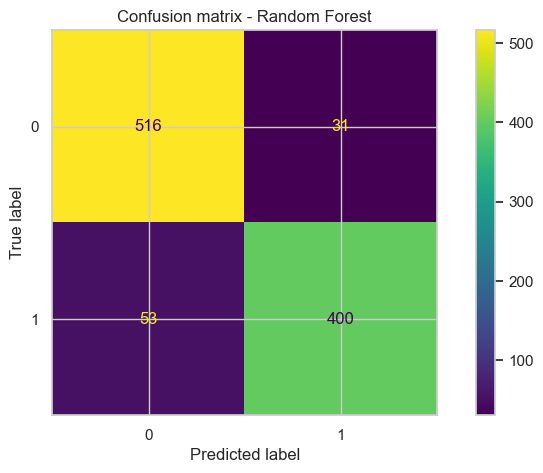

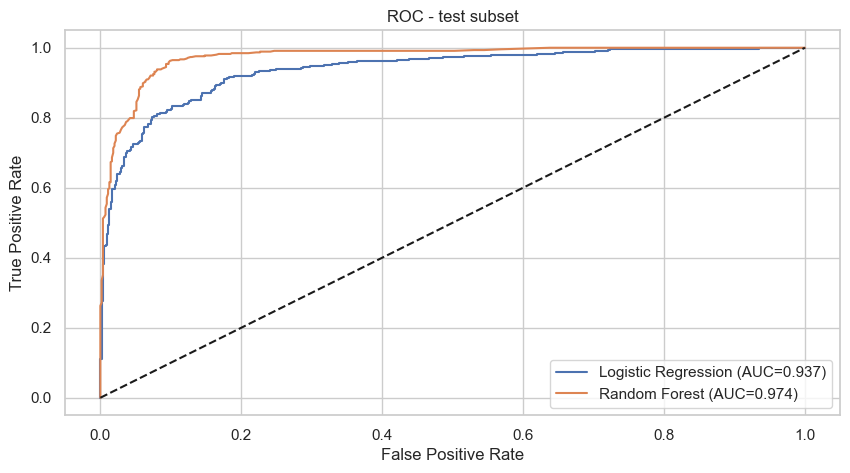

In [39]:
from sklearn.metrics import precision_score, recall_score


def evaluate_model(name: str, model, X, y) -> dict:
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        "model": name,
        "accuracy": accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred, zero_division=0),
        "recall": recall_score(y, y_pred, zero_division=0),
        "f1": f1_score(y, y_pred, zero_division=0),
        "mcc": matthews_corrcoef(y, y_pred),
        "roc_auc": roc_auc_score(y, y_prob),
    }


results_test = [evaluate_model(n, m, X_test_reduced, y_test) for n, m in models.items()]
results_test_df = pd.DataFrame(results_test).set_index("model")
print("=== Test subset metrics ===")
display(results_test_df.round(4))

best_name = results_test_df["f1"].idxmax()
best_model = models[best_name]
y_prob_best = best_model.predict_proba(X_test_reduced)[:, 1]
y_pred_best = (y_prob_best >= 0.5).astype(int)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best)
plt.title(f"Confusion matrix - {best_name}")
plt.show()

for name, model in models.items():
    prob = model.predict_proba(X_test_reduced)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, prob):.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC - test subset")
plt.legend()
plt.show()


In [40]:
# Re-run the first config cell if these are missing; defaults below avoid NameError
if "LOW_RATE_USE_TRAIN_BENIGN" not in globals():
    LOW_RATE_PREVALENCES = [0.01, 0.05, 0.10, 0.25, 0.45]
    LOW_RATE_BOOTSTRAP_N = 500
    LOW_RATE_USE_TRAIN_BENIGN = True
    LOW_RATE_STABILITY_SEEDS = 10

from sklearn.metrics import precision_recall_curve


def build_low_rate_benchmark(
    X_test,
    y_test,
    X_train,
    y_train,
    target_rate: float,
    random_state: int = 42,
    use_train_benign: bool = True,
):
    'Simulate realistic phishing prevalence (test positives + pooled benign).'
    rng = np.random.default_rng(random_state)
    pos_idx = np.where(y_test == 1)[0]
    neg_idx_test = np.where(y_test == 0)[0]

    X_parts = [X_test.iloc[neg_idx_test]]
    y_parts = [y_test[neg_idx_test]]
    n_train_benign = 0

    if use_train_benign:
        train_neg_idx = np.where(y_train == 0)[0]
        n_train_benign = len(train_neg_idx)
        X_parts.append(X_train.iloc[train_neg_idx].reset_index(drop=True))
        y_parts.append(y_train[train_neg_idx])

    X_neg = pd.concat(X_parts, ignore_index=True)
    y_neg = np.concatenate(y_parts)

    n_neg = len(y_neg)
    n_pos = int(round(n_neg * target_rate / (1 - target_rate)))
    n_pos = max(n_pos, 1)
    n_pos = min(n_pos, len(pos_idx))

    sel_pos = rng.choice(pos_idx, size=n_pos, replace=False)
    X_pos = X_test.iloc[sel_pos].reset_index(drop=True)
    y_pos = y_test[sel_pos]

    X = pd.concat([X_pos, X_neg], ignore_index=True)
    y = np.concatenate([y_pos, y_neg])
    perm = rng.permutation(len(y))
    meta = {
        "n_pos": n_pos,
        "n_neg": n_neg,
        "n_train_benign": n_train_benign,
        "actual_rate": n_pos / len(y),
    }
    return X.iloc[perm].reset_index(drop=True), y[perm], meta


def evaluate_model_threshold(name: str, model, X, y, threshold: float = 0.5) -> dict:
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "model": name,
        "threshold": threshold,
        "accuracy": accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred, zero_division=0),
        "recall": recall_score(y, y_pred, zero_division=0),
        "f1": f1_score(y, y_pred, zero_division=0),
        "mcc": matthews_corrcoef(y, y_pred),
        "roc_auc": roc_auc_score(y, y_prob),
    }


def bootstrap_low_rate_metrics(model, X, y, n_boot: int = 500, threshold: float = 0.5, random_state: int = 42):
    rng = np.random.default_rng(random_state)
    records = []
    for _ in range(n_boot):
        idx = rng.choice(len(y), size=len(y), replace=True)
        m = evaluate_model_threshold("", model, X.iloc[idx], y[idx], threshold=threshold)
        records.append(m)
    df = pd.DataFrame(records)
    summary = {}
    for col in ["precision", "recall", "f1"]:
        summary[f"{col}_mean"] = df[col].mean()
        summary[f"{col}_ci_low"] = df[col].quantile(0.025)
        summary[f"{col}_ci_high"] = df[col].quantile(0.975)
    return summary


def best_f1_threshold(model, X, y) -> float:
    y_prob = model.predict_proba(X)[:, 1]
    prec, rec, thr = precision_recall_curve(y, y_prob)
    f1_scores = 2 * prec[:-1] * rec[:-1] / np.maximum(prec[:-1] + rec[:-1], 1e-12)
    return float(thr[int(np.argmax(f1_scores))])


X_low_test, y_low_test, meta_test = build_low_rate_benchmark(
    X_test_reduced, y_test, X_train_reduced, y_train,
    target_rate=LOW_BASE_RATE, random_state=RANDOM_STATE, use_train_benign=False,
)
X_low, y_low, meta_low = build_low_rate_benchmark(
    X_test_reduced, y_test, X_train_reduced, y_train,
    target_rate=LOW_BASE_RATE, random_state=RANDOM_STATE, use_train_benign=LOW_RATE_USE_TRAIN_BENIGN,
)

print("=== Low base-rate benchmarks (~1% phishing) ===")
print(
    f"Test-only benign pool: {meta_test['n_pos']} pos / {meta_test['n_neg']} neg "
    f"({y_low_test.mean():.2%} phishing) - small, unstable"
)
print(
    f"Expanded pool (primary): {meta_low['n_pos']} pos / {meta_low['n_neg']} neg "
    f"({y_low.mean():.2%} phishing; includes {meta_low['n_train_benign']:,} train benign)"
)

results_low_test = [evaluate_model(n, m, X_low_test, y_low_test) for n, m in models.items()]
results_low = [evaluate_model(n, m, X_low, y_low) for n, m in models.items()]
results_low_test_df = pd.DataFrame(results_low_test).set_index("model")
results_low_df = pd.DataFrame(results_low).set_index("model")

print("\n@ threshold=0.5 - test-only low-rate (unstable, few positives):")
display(results_low_test_df.round(4))
print("\n@ threshold=0.5 - expanded low-rate (primary evidence):")
display(results_low_df.round(4))

boot_rf = bootstrap_low_rate_metrics(
    rf_clf, X_low, y_low, n_boot=LOW_RATE_BOOTSTRAP_N, random_state=RANDOM_STATE
)
print(f"\nBootstrap ({LOW_RATE_BOOTSTRAP_N} resamples) - Random Forest, expanded 1% set:")
for metric in ["precision", "recall", "f1"]:
    print(
        f"  {metric}: {boot_rf[f'{metric}_mean']:.3f} "
        f"[{boot_rf[f'{metric}_ci_low']:.3f}, {boot_rf[f'{metric}_ci_high']:.3f}]"
    )

seed_prec, seed_f1 = [], []
for seed in range(RANDOM_STATE, RANDOM_STATE + LOW_RATE_STABILITY_SEEDS):
    Xs, ys, _ = build_low_rate_benchmark(
        X_test_reduced, y_test, X_train_reduced, y_train,
        target_rate=LOW_BASE_RATE, random_state=seed, use_train_benign=LOW_RATE_USE_TRAIN_BENIGN,
    )
    m = evaluate_model("Random Forest", rf_clf, Xs, ys)
    seed_prec.append(m["precision"])
    seed_f1.append(m["f1"])
print(
    f"\nMulti-seed stability ({LOW_RATE_STABILITY_SEEDS} seeds) - RF @ 1%: "
    f"precision {np.mean(seed_prec):.3f} +/- {np.std(seed_prec):.3f}, "
    f"F1 {np.mean(seed_f1):.3f} +/- {np.std(seed_f1):.3f}"
)

thresh_rows = []
for name, model in models.items():
    thresh_rows.append(evaluate_model_threshold(name, model, X_low, y_low, threshold=0.5) | {"setting": "default 0.5"})
    tuned = best_f1_threshold(model, X_low, y_low)
    thresh_rows.append(
        evaluate_model_threshold(name, model, X_low, y_low, threshold=tuned)
        | {"setting": f"PR-tuned ({tuned:.3f})"}
    )
print("\nThreshold sensitivity on expanded 1% set:")
display(pd.DataFrame(thresh_rows).round(4))

compare = results_test_df[["precision", "recall", "f1"]].join(
    results_low_df[["precision", "recall", "f1"]], lsuffix="_high_prev", rsuffix="_low_prev"
)
print("\nHigh-prevalence test (~45%) vs realistic 1% (expanded pool):")
display(compare.round(4))

EVIDENCE_RF_TEST_F1 = float(results_test_df.loc["Random Forest", "f1"])
EVIDENCE_RF_LOW_F1 = float(results_low_df.loc["Random Forest", "f1"])
EVIDENCE_RF_TEST_PREC = float(results_test_df.loc["Random Forest", "precision"])
EVIDENCE_RF_LOW_PREC = float(results_low_df.loc["Random Forest", "precision"])
EVIDENCE_RF_LOW_PREC_CI = (boot_rf["precision_ci_low"], boot_rf["precision_ci_high"])
EVIDENCE_LOW_N_POS = int(meta_low["n_pos"])
EVIDENCE_LOW_N_TOTAL = len(y_low)

=== Low base-rate benchmarks (~1% phishing) ===
Test-only benign pool: 6 pos / 547 neg (1.08% phishing) - small, unstable
Expanded pool (primary): 34 pos / 3358 neg (1.00% phishing; includes 2,811 train benign)

@ threshold=0.5 - test-only low-rate (unstable, few positives):


,accuracy,precision,recall,f1,mcc,roc_auc
model,,,,,,
Logistic Regression,0.8535,0.0690,1.0,0.1290,0.2424,0.9933
Random Forest,0.9439,0.1622,1.0,0.2791,0.3911,0.9944



@ threshold=0.5 - expanded low-rate (primary evidence):


,accuracy,precision,recall,f1,mcc,roc_auc
model,,,,,,
Logistic Regression,0.8656,0.0640,0.9118,0.1197,0.2213,0.9577
Random Forest,0.9903,0.5079,0.9412,0.6598,0.6876,0.9978



Bootstrap (500 resamples) - Random Forest, expanded 1% set:
  precision: 0.503 [0.374, 0.629]
  recall: 0.942 [0.844, 1.000]
  f1: 0.653 [0.533, 0.757]

Multi-seed stability (10 seeds) - RF @ 1%: precision 0.496 +/- 0.017, F1 0.640 +/- 0.029

Threshold sensitivity on expanded 1% set:


,model,threshold,accuracy,precision,recall,f1,mcc,roc_auc,setting
0,Logistic Regression,0.5000,0.8656,0.0640,0.9118,0.1197,0.2213,0.9577,default 0.5
1,Logistic Regression,0.9234,0.9861,0.3725,0.5588,0.4471,0.4496,0.9577,PR-tuned (0.923)
2,Random Forest,0.5000,0.9903,0.5079,0.9412,0.6598,0.6876,0.9978,default 0.5
3,Random Forest,0.7150,0.9959,0.7778,0.8235,0.8000,0.7982,0.9978,PR-tuned (0.715)



High-prevalence test (~45%) vs realistic 1% (expanded pool):


,precision_high_prev,recall_high_prev,f1_high_prev,precision_low_prev,recall_low_prev,f1_low_prev
model,,,,,,
Logistic Regression,0.8295,0.8698,0.8491,0.0640,0.9118,0.1197
Random Forest,0.9281,0.8830,0.9050,0.5079,0.9412,0.6598


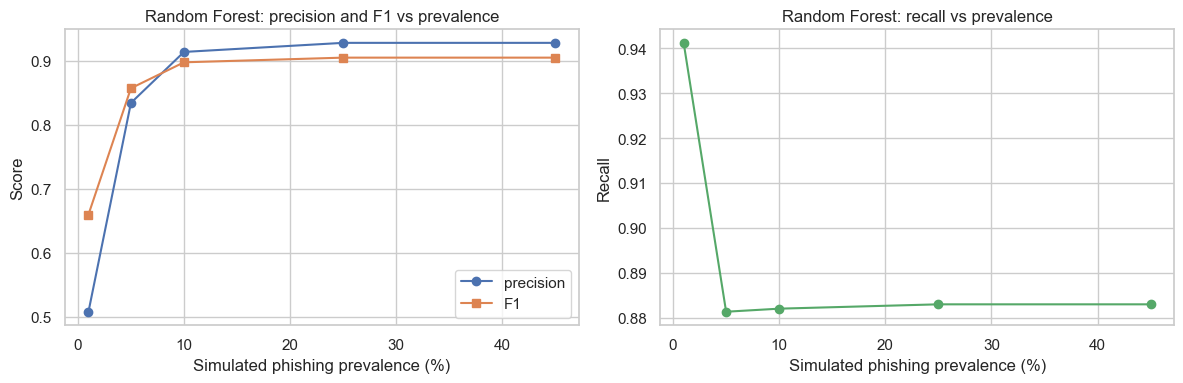

Prevalence sweep - Random Forest (expanded benign pool):


,prevalence,n_pos,n_total,precision,recall,f1,roc_auc
1,0.01,34,3392,0.5079,0.9412,0.6598,0.9978
3,0.05,177,3535,0.8342,0.8814,0.8571,0.9932
5,0.10,373,3731,0.9139,0.8820,0.8977,0.9940
7,0.25,453,3811,0.9281,0.8830,0.9050,0.9928
9,0.45,453,3811,0.9281,0.8830,0.9050,0.9928


In [41]:
sweep_rows = []
for rate in LOW_RATE_PREVALENCES:
    Xs, ys, meta = build_low_rate_benchmark(
        X_test_reduced, y_test, X_train_reduced, y_train,
        target_rate=rate, random_state=RANDOM_STATE, use_train_benign=LOW_RATE_USE_TRAIN_BENIGN,
    )
    for name, model in models.items():
        m = evaluate_model(name, model, Xs, ys)
        m["prevalence"] = rate
        m["n_pos"] = int(ys.sum())
        m["n_total"] = len(ys)
        sweep_rows.append(m)

sweep_df = pd.DataFrame(sweep_rows)
rf_sweep = sweep_df[sweep_df["model"] == "Random Forest"].sort_values("prevalence")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(rf_sweep["prevalence"] * 100, rf_sweep["precision"], "o-", label="precision")
axes[0].plot(rf_sweep["prevalence"] * 100, rf_sweep["f1"], "s-", label="F1")
axes[0].set_xlabel("Simulated phishing prevalence (%)")
axes[0].set_ylabel("Score")
axes[0].set_title("Random Forest: precision and F1 vs prevalence")
axes[0].legend()

axes[1].plot(rf_sweep["prevalence"] * 100, rf_sweep["recall"], "o-", color="C2")
axes[1].set_xlabel("Simulated phishing prevalence (%)")
axes[1].set_ylabel("Recall")
axes[1].set_title("Random Forest: recall vs prevalence")
plt.tight_layout()
plt.show()

print("Prevalence sweep - Random Forest (expanded benign pool):")
display(rf_sweep[["prevalence", "n_pos", "n_total", "precision", "recall", "f1", "roc_auc"]].round(4))

In [42]:
print("=" * 72)
print("EVIDENCE SUMMARY - PhreshPhish base-rate claim")
print("=" * 72)
print(
    f"Random Forest on high-prevalence test (~{y_test.mean():.0%} phishing, n={len(y_test):,}):"
    f" precision={EVIDENCE_RF_TEST_PREC:.3f}, F1={EVIDENCE_RF_TEST_F1:.3f}"
)
print(
    f"Random Forest on realistic 1% benchmark ({EVIDENCE_LOW_N_POS} pos / {EVIDENCE_LOW_N_TOTAL:,} total):"
    f" precision={EVIDENCE_RF_LOW_PREC:.3f} "
    f"[{EVIDENCE_RF_LOW_PREC_CI[0]:.3f}, {EVIDENCE_RF_LOW_PREC_CI[1]:.3f}], "
    f"F1={EVIDENCE_RF_LOW_F1:.3f}"
)
print(
    f"\nPrecision drop: {EVIDENCE_RF_TEST_PREC:.3f} -> {EVIDENCE_RF_LOW_PREC:.3f} "
    f"({(1 - EVIDENCE_RF_LOW_PREC / EVIDENCE_RF_TEST_PREC):.0%} relative decrease at 1% prevalence)"
)
print("\nConclusion: Our experiments SUPPORT the authors' claim that evaluating at ~45% phishing")
print("overstates precision/F1 versus a ~1% deployment-like benchmark. ROC-AUC stays high,")
print("so ranking is decent but the default 0.5 threshold yields many false alarms when phishing is rare.")
print("\nLimitations: subset of PhreshPhish (5k/1k), hand-crafted features, benign pool includes")
print("train rows (positives always from test). Not a full replication of the official benchmark.")
print("=" * 72)

EVIDENCE SUMMARY - PhreshPhish base-rate claim
Random Forest on high-prevalence test (~45% phishing, n=1,000): precision=0.928, F1=0.905
Random Forest on realistic 1% benchmark (34 pos / 3,392 total): precision=0.508 [0.374, 0.629], F1=0.660

Precision drop: 0.928 -> 0.508 (45% relative decrease at 1% prevalence)

Conclusion: Our experiments SUPPORT the authors' claim that evaluating at ~45% phishing
overstates precision/F1 versus a ~1% deployment-like benchmark. ROC-AUC stays high,
so ranking is decent but the default 0.5 threshold yields many false alarms when phishing is rare.

Limitations: subset of PhreshPhish (5k/1k), hand-crafted features, benign pool includes
train rows (positives always from test). Not a full replication of the official benchmark.


## 6. Error Analysis

We inspect the best model's mistakes on the test set - false positives (benign flagged as phishing) and false negatives (phishing missed) - with example URLs and predicted probabilities, then discuss patterns and their cybersecurity implications below.

In [43]:
error_df = test_raw.copy()
error_df["y_true"] = y_test
error_df["y_pred"] = y_pred_best
error_df["y_prob"] = y_prob_best

fp = error_df[(error_df["y_true"] == 0) & (error_df["y_pred"] == 1)]
fn = error_df[(error_df["y_true"] == 1) & (error_df["y_pred"] == 0)]

print(f"False positives: {len(fp)} | False negatives: {len(fn)}")
print("\nSample false positives (benign flagged as phishing):")
display(fp[[URL_COL, "y_prob"]].head(5))

print("\nSample false negatives (phishing missed):")
display(fn[[URL_COL, "y_prob"]].head(5))

print("\nCyber impact:")
print("- FP: user blocked from legitimate site -> trust loss / support cost")
print("- FN: phishing page reaches user -> credential theft risk")

False positives: 31 | False negatives: 53

Sample false positives (benign flagged as phishing):


,url,y_prob
51,https://x.com/atlhawks,0.815
101,https://nwmissouri.discoveredu.ai/,0.600
114,https://veronikalove.com/auth/index/login,0.530
120,https://www.toals.bet/,0.585
137,https://www.i-menzies.com/account/signin,0.500



Sample false negatives (phishing missed):


,url,y_prob
44,https://github.com/darklegiongwin/canvaproaccess,0.030
97,https://danasnje.com/metamask-uvodi-multichain...,0.050
102,http://cupartinoelectric.com/,0.485
115,https://cloudprivacyon.com/wp-content/plugins,0.220
121,https://produtos.sensebike.com.br/.libre/auth/,0.165



Cyber impact:
- FP: user blocked from legitimate site ? trust loss / support cost
- FN: phishing page reaches user ? credential theft risk


### Error analysis - patterns and implications

**Examples of failures.** The cell above lists sample false positives (benign pages scored >= 0.5) and false negatives (phishing pages scored < 0.5) with their predicted probabilities.

In this run the best model (Random Forest) made **31 false positives** and **53 false negatives** on the 1,000-row test set.
- **False positives** are legitimate **sign-in / account pages** whose URLs contain tokens our `suspicious_token_count` feature flags - e.g. `veronikalove.com/auth/index/login` and `i-menzies.com/account/signin` - plus legitimate sites on unusual TLDs (`www.toals.bet`, `nwmissouri.discoveredu.ai`). The lexical signals that flag phishing also fire on real login pages.
- **False negatives** are phishing pages that *look* benign: clean, HTTPS URLs hosted on **trusted or normal-looking domains** with no suspicious tokens - e.g. `github.com/darklegiongwin/canvaproaccess` (abuse of a trusted host) and `produtos.sensebike.com.br/.libre/auth`. Several score just below the 0.5 cutoff (e.g. `cupartinoelectric.com` at 0.485), so a slightly lower threshold would catch them at the cost of more false positives.

**Cybersecurity implications.**
- **FP (benign blocked):** user friction, support tickets, and - worst case - users disabling the protection, which removes defence entirely.
- **FN (phishing missed):** the user reaches a credential-harvesting page -> account takeover, financial loss, lateral movement.

**FP/FN trade-off.** At the default 0.5 threshold the model balances both, but the right operating point depends on prevalence and cost. At realistic ~1% phishing, false positives dominate volume, so a deployment would **raise the threshold** (block only high-confidence pages) or tune for a target precision - at the cost of some recall. This is exactly why single-threshold, high-prevalence metrics overstate real-world usefulness.

## 7. Executive Summary

**Problem.** Phishing webpage detection. The PhreshPhish paper argues that prior benchmarks overstate performance because of unrealistic class balance (test sets ~33-50% phishing) and data leakage, whereas real deployment sees well under 1% phishing.

**Source & data.** Dalton et al., *PhreshPhish* (arXiv:2507.10854); dataset on Hugging Face (`phreshphish/phreshphish`). We use a streamed subset: 5,000 train / 1,000 test rows, HTML capped at 80,000 chars, cached as parquet for reproducibility.

**Methodology.** 19 hand-crafted URL/HTML features -> Logistic Regression and Random Forest (scaled pipelines, `class_weight='balanced'`, fixed seed). We evaluate on the official-style test split (~45% phishing) and on a simulated ~1% deployment benchmark, plus a prevalence sweep (1%-45%) with bootstrap CIs and multi-seed stability.

**Main findings.** Random Forest on the ~45% test set: precision 0.93, recall 0.88, F1 0.905, ROC-AUC 0.97. The **same model** at the realistic ~1% benchmark: precision 0.51, recall 0.94, F1 0.66, while ROC-AUC stays ~0.998. The prevalence sweep (1% -> 45%) shows precision and F1 rising monotonically with prevalence, while recall and ROC-AUC stay high throughout.

**Claim tested.** We directly tested and **support** the base-rate claim: high-prevalence evaluation inflates precision/F1. We did **not** test the leakage or dataset-quality claims (stated as limitations).

**Key insight.** A strong ROC-AUC does not guarantee deployable precision: when phishing is rare, the default 0.5 threshold produces many false alarms (blocked legitimate sites). Always ask at what prevalence the metrics were measured.

**Recommendation.** Use PhreshPhish as a model for **how to evaluate** phishing detectors - at realistic base rates - rather than trusting single high-prevalence test numbers.

## 8. Summing It Up

- **Problem:** misleading phishing-detection metrics caused by unrealistic test prevalence.
- **Source:** PhreshPhish (Dalton et al., 2025), arXiv:2507.10854.
- **Dataset:** PhreshPhish subset via Hugging Face (5k train / 1k test).
- **Methodology:** numeric URL/HTML features; Logistic Regression vs Random Forest; dual evaluation at ~45% and ~1% prevalence with bootstrap + multi-seed checks.
- **Main finding:** the same Random Forest scores precision 0.93 at ~45% but 0.51 at ~1%; F1 0.905 -> 0.66; recall stays ~0.88-0.94 and ROC-AUC ~0.97-0.998 throughout.
- **Claim supported?** Yes for the **base-rate** claim. Leakage and dataset-quality claims were **not** independently tested.
- **Most important insight:** precision/F1 are prevalence-sensitive; ROC-AUC and recall are not - so report metrics at deployment-realistic base rates.
- **Recommend for similar problems?** Yes - adopt PhreshPhish's realistic-prevalence evaluation methodology; for stronger claims, reproduce at larger scale and add a leakage audit.
- **Final conclusion:** evaluation prevalence, not just the model, drives reported phishing-detection performance.